# Partie I – MLP et ingénierie PyTorch

Classification sur **Breast Cancer Wisconsin** (données tabulaires).

- `nn.Sequential` vs classe personnalisée
- Initialisations : gaussienne, constante, Xavier
- Sauvegarde / rechargement, métriques de classification

> Exécuter les cellules dans l'ordre. Les figures s'affichent sous chaque cellule et sont aussi enregistrées dans `figures/`.


In [45]:
%matplotlib inline
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "partie1_mlp").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)



## Configuration et imports


In [46]:
import copy
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
FIG_DIR = ROOT / "DL_1" / "mlp" / "figures" 
MODEL_DIR = ROOT / "DL_1" / "mlp" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

INPUT_DIM = 30
HIDDEN_DIM = 64
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 10
INIT_EPOCHS = 5  # comparaison des initialisations (mode rapide)
LR = 1e-3
print(f"Using device: {DEVICE}")


Using device: mps


## 1. Modèles MLP : Sequential vs classe personnalisée


In [47]:
class MLPSequential(nn.Module):
    """MLP construit avec nn.Sequential."""

    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class MLPCustom(nn.Module):
    """MLP avec classe personnalisée (équivalent fonctionnel)."""

    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x)


## 2. Initialisation des poids


In [48]:
def init_weights_gaussian(m: nn.Module, mean: float = 0.0, std: float = 0.1):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=mean, std=std)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def init_weights_constant(m: nn.Module, value: float = 0.01):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, value)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def init_weights_xavier(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


INIT_STRATEGIES = {
    "gaussian": init_weights_gaussian,
    "constant": init_weights_constant,
    "xavier": init_weights_xavier,
}


## 3. Préparation des données


In [49]:
def prepare_data():
    data = load_breast_cancer()
    X, y = data.data, data.target

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    def to_loader(X_arr, y_arr, shuffle=False):
        ds = TensorDataset(
            torch.tensor(X_arr, dtype=torch.float32),
            torch.tensor(y_arr, dtype=torch.long),
        )
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

    return {
        "train": to_loader(X_train, y_train, shuffle=True),
        "val": to_loader(X_val, y_val),
        "test": to_loader(X_test, y_test),
        "feature_names": data.feature_names,
        "target_names": data.target_names,
    }


## 4. Entraînement et évaluation


In [50]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }
    return avg_loss, metrics, all_labels, all_preds


def train_model(model, loaders, init_name: str, model_type: str, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss = train_epoch(model, loaders["train"], criterion, optimizer, DEVICE)
        val_loss, val_metrics, _, _ = evaluate(model, loaders["val"], criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_val_acc


def inspect_model(model: nn.Module, title: str):
    print(f"\n{'='*60}")
    print(f"Inspection : {title}")
    print(f"{'='*60}")
    print("\n--- named_parameters() ---")
    for name, param in model.named_parameters():
        print(f"  {name}: shape={tuple(param.shape)}, requires_grad={param.requires_grad}")
    print("\n--- state_dict() keys ---")
    for key in model.state_dict().keys():
        print(f"  {key}")


def plot_confusion_matrix(labels, preds, target_names, save_path):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=target_names, yticklabels=target_names,
    )
    plt.xlabel("Prédiction")
    plt.ylabel("Vérité terrain")
    plt.title("Matrice de confusion – MLP (test)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def plot_training_curves(histories, save_path):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    for label, h in histories.items():
        plt.plot(h["val_acc"], label=label)
    plt.xlabel("Époque")
    plt.ylabel("Accuracy (validation)")
    plt.legend(fontsize=8)
    plt.title("Convergence – initialisation")

    plt.subplot(1, 2, 2)
    for label, h in histories.items():
        plt.plot(h["val_loss"], label=label)
    plt.xlabel("Époque")
    plt.ylabel("Loss (validation)")
    plt.legend(fontsize=8)
    plt.title("Loss – initialisation")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## 5. Exécution


## Expériences


### Préparation


In [51]:
print(f"Device utilisé : {DEVICE}")
loaders = prepare_data()
print(f"Train: {len(loaders['train'].dataset)} | Val: {len(loaders['val'].dataset)} | Test: {len(loaders['test'].dataset)}")


Device utilisé : mps
Train: 398 | Val: 85 | Test: 86


### Comparaison des initialisations (MLP Sequential)


Init gaussian: best val accuracy = 0.9765
Init constant: best val accuracy = 0.9647
Init xavier: best val accuracy = 0.9765


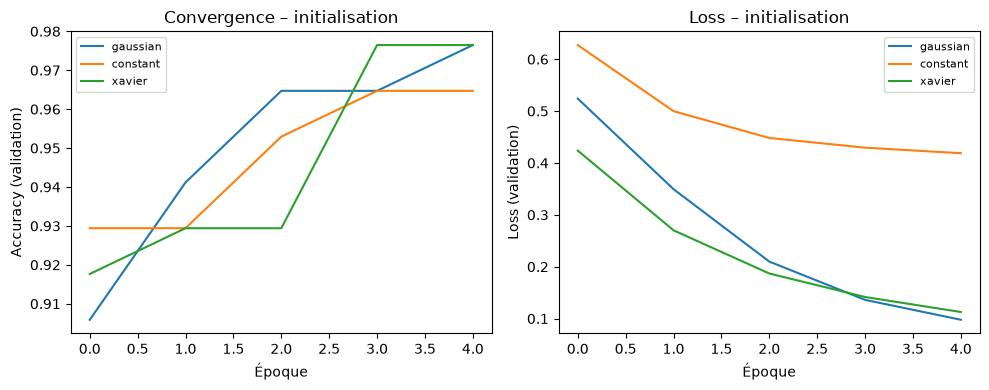

In [52]:
init_results = {}
init_histories = {}

for init_name, init_fn in INIT_STRATEGIES.items():
    model = MLPSequential(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES)
    model.apply(init_fn)
    model, history, best_val = train_model(model, loaders, init_name, "sequential", epochs=INIT_EPOCHS)
    init_results[init_name] = best_val
    init_histories[init_name] = history
    print(f"Init {init_name}: best val accuracy = {best_val:.4f}")

plot_training_curves(init_histories, FIG_DIR / "init_comparison.png")


### Meilleure initialisation


In [53]:
best_init = max(init_results, key=init_results.get)
print(f"\nMeilleure initialisation : {best_init} ({init_results[best_init]:.4f})")



Meilleure initialisation : gaussian (0.9765)


### Modèle final : Sequential vs Custom


In [54]:
results_comparison = {}
sequential_for_save = None
for model_cls, name in [(MLPSequential, "Sequential"), (MLPCustom, "Custom")]:
    model = model_cls(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES)
    model.apply(INIT_STRATEGIES[best_init])

    inspect_model(model, f"MLP {name} (avant entraînement)")
    model, _, _ = train_model(model, loaders, best_init, name.lower())

    criterion = nn.CrossEntropyLoss()
    _, test_metrics, y_true, y_pred = evaluate(model, loaders["test"], criterion, DEVICE)
    results_comparison[name] = test_metrics
    if name == "Sequential":
        sequential_for_save = model
    print(f"\n--- MLP {name} – Test ---")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")



Inspection : MLP Sequential (avant entraînement)

--- named_parameters() ---
  net.0.weight: shape=(64, 30), requires_grad=True
  net.0.bias: shape=(64,), requires_grad=True
  net.3.weight: shape=(32, 64), requires_grad=True
  net.3.bias: shape=(32,), requires_grad=True
  net.6.weight: shape=(2, 32), requires_grad=True
  net.6.bias: shape=(2,), requires_grad=True

--- state_dict() keys ---
  net.0.weight
  net.0.bias
  net.3.weight
  net.3.bias
  net.6.weight
  net.6.bias

--- MLP Sequential – Test ---
  accuracy: 0.9535
  precision: 0.9310
  recall: 1.0000
  f1: 0.9643

Inspection : MLP Custom (avant entraînement)

--- named_parameters() ---
  fc1.weight: shape=(64, 30), requires_grad=True
  fc1.bias: shape=(64,), requires_grad=True
  fc2.weight: shape=(32, 64), requires_grad=True
  fc2.bias: shape=(32,), requires_grad=True
  fc3.weight: shape=(2, 32), requires_grad=True
  fc3.bias: shape=(2,), requires_grad=True

--- state_dict() keys ---
  fc1.weight
  fc1.bias
  fc2.weight
  fc2.b

### Sauvegarde / rechargement (réutilise le Sequential déjà entraîné)


In [55]:
best_model = sequential_for_save
save_path = MODEL_DIR / "best_mlp.pt"
torch.save({
    "state_dict": best_model.state_dict(),
    "init": best_init,
    "input_dim": INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_classes": NUM_CLASSES,
}, save_path)
print(f"\nModèle sauvegardé : {save_path}")



Modèle sauvegardé : /Users/iksi/Documents/DL_1/mlp/models/best_mlp.pt


### Rechargement



--- Modèle rechargé – Test ---
  accuracy: 0.9535
  precision: 0.9310
  recall: 1.0000
  f1: 0.9643


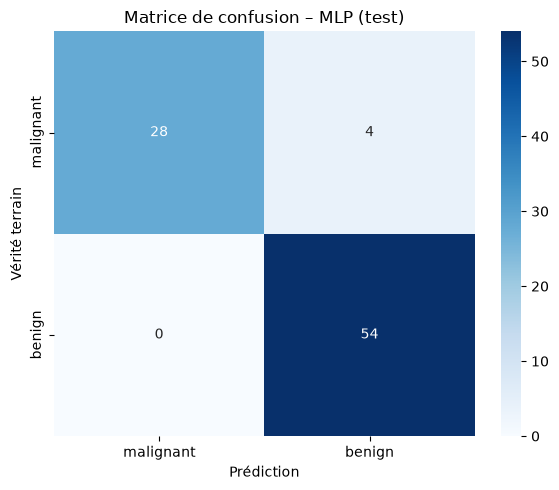

In [56]:
checkpoint = torch.load(save_path, map_location=DEVICE)
reloaded = MLPSequential(
    checkpoint["input_dim"], checkpoint["hidden_dim"], checkpoint["num_classes"]
)
reloaded.load_state_dict(checkpoint["state_dict"])
reloaded = reloaded.to(DEVICE)

criterion = nn.CrossEntropyLoss()
_, reloaded_metrics, y_true, y_pred = evaluate(reloaded, loaders["test"], criterion, DEVICE)
print("\n--- Modèle rechargé – Test ---")
for k, v in reloaded_metrics.items():
    print(f"  {k}: {v:.4f}")

plot_confusion_matrix(y_true, y_pred, loaders["target_names"], FIG_DIR / "confusion_matrix.png")


### Vérification cohérence device


In [57]:
sample = next(iter(loaders["test"]))
x_sample = sample[0].to(DEVICE)
model_device = next(reloaded.parameters()).device
assert x_sample.device == model_device
with torch.no_grad():
    out = reloaded(x_sample)
print(f"\nCohérence device OK : input={x_sample.device}, output shape={out.shape}")



Cohérence device OK : input=mps:0, output shape=torch.Size([32, 2])


### Export résultats


In [58]:
summary = {
    "device": str(DEVICE),
    "init_comparison": init_results,
    "best_init": best_init,
    "model_comparison": results_comparison,
    "reloaded_test": reloaded_metrics,
}
with open(ROOT / "partie1_mlp" / "results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nClassification report (modèle rechargé):")
print(classification_report(y_true, y_pred, target_names=loaders["target_names"]))
print(f"\nFigures sauvegardées dans {FIG_DIR}")



Classification report (modèle rechargé):
              precision    recall  f1-score   support

   malignant       1.00      0.88      0.93        32
      benign       0.93      1.00      0.96        54

    accuracy                           0.95        86
   macro avg       0.97      0.94      0.95        86
weighted avg       0.96      0.95      0.95        86


Figures sauvegardées dans /Users/iksi/Documents/DL_1/mlp/figures
